In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from PIL import Image
import os
import cv2
from jiwer import wer, cer


In [2]:
CARACTERES = " !\"#&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz\n"
char_a_idx = {char: idx + 1 for idx, char in enumerate(CARACTERES)} 
idx_a_char = {idx + 1: char for idx, char in enumerate(CARACTERES)}
idx_a_char[0] = "" # CTC Blank token
NUM_CLASES = len(CARACTERES) + 1 


In [10]:
# ==========================================
# 1. UTILS
# ==========================================
def texto_a_tensor(texto):
    indices = [char_a_idx.get(c, 0) for c in str(texto)] 
    return torch.tensor([i for i in indices if i != 0], dtype=torch.long)

def calcular_cer(prediccion, real):
    if len(real) == 0: return 1.0
    d = np.zeros((len(prediccion) + 1, len(real) + 1))
    for i in range(len(prediccion) + 1): d[i, 0] = i
    for j in range(len(real) + 1): d[0, j] = j
    for i in range(1, len(prediccion) + 1):
        for j in range(1, len(real) + 1):
            costo = 0 if prediccion[i-1] == real[j-1] else 1
            d[i, j] = min(d[i-1, j] + 1, d[i, j-1] + 1, d[i-1, j-1] + costo)
    return d[len(prediccion), len(real)] / len(real)

def decodificar_prediccion(tensor_prediccion):
    pred_indices = torch.argmax(tensor_prediccion[:, 0, :], dim=1).detach().cpu().numpy()
    texto_decodificado = []
    idx_anterior = -1
    for idx in pred_indices:
        if idx != 0 and idx != idx_anterior:
            texto_decodificado.append(idx_a_char.get(idx, ""))
        idx_anterior = idx
    return "".join(texto_decodificado)



def visualizar_canales_especificos(x_fused, x_row, x_col, lista_canales, batch_index=0):
    # Pasamos los tensores a CPU
    fused_feat = x_fused[batch_index].detach().cpu()
    row_feat = x_row[batch_index].detach().cpu()
    col_feat = x_col[batch_index].detach().cpu()
    
    num_columnas = len(lista_canales)
    
    fig, axes = plt.subplots(nrows=3, ncols=num_columnas, figsize=(num_columnas * 2.5, 6))
    
    nombres_filas = ['1. Row LSTM', '2. Col LSTM', '3. Row-Col Fusión']
    tensores = [row_feat, col_feat, fused_feat]
    
    for fila_idx, (nombre, tensor) in enumerate(zip(nombres_filas, tensores)):
        axes[fila_idx, 0].set_ylabel(nombre, size='large', weight='bold')
        
        # Guardamos la cantidad real de canales de este tensor (128 o 256)
        max_canales = tensor.shape[0] 
        
        for col_idx, canal_real in enumerate(lista_canales):
            ax = axes[fila_idx, col_idx]
            
            # EL ARREGLO: Verificamos contra el tamaño real del tensor actual
            if canal_real < max_canales:
                ax.imshow(tensor[canal_real], cmap='viridis', aspect='auto')
                if fila_idx == 0:
                    ax.set_title(f"Channel {canal_real}")
            else:
                # Si pedimos un canal (ej. 130) y el tensor no lo tiene, lo apagamos
                ax.axis('off')
                if fila_idx == 0:
                    ax.set_title(f"Channel {canal_real}\n(Vacío)")
            
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.savefig('../results/visualizacion_canales.png', dpi=300)
    plt.show()

In [4]:
class RowColLSTM(nn.Module):
    def __init__(self, in_channels, hidden_size):
        super().__init__()
        self.row_lstm = nn.LSTM(in_channels, hidden_size, bidirectional=True, batch_first=True)
        self.col_lstm = nn.LSTM(in_channels, hidden_size, bidirectional=True, batch_first=True)
        self.fusion = nn.Conv2d(hidden_size * 4, in_channels, kernel_size=1)

    def forward(self, x):
        b, c, h, w = x.size()
        
        # 1. Procesamiento Row y Col
        out_rows, _ = self.row_lstm(x.permute(0, 2, 3, 1).contiguous().view(b * h, w, c))
        out_cols, _ = self.col_lstm(x.permute(0, 3, 2, 1).contiguous().view(b * w, h, c))
        
        # 2. Deshacer el truco de dimensiones
        row_reshaped = out_rows.view(b, h, w, -1).permute(0, 3, 1, 2)
        col_reshaped = out_cols.view(b, w, h, -1).permute(0, 3, 2, 1)
        
        # 3. Fusión
        fused = F.relu(self.fusion(torch.cat([row_reshaped, col_reshaped], dim=1)))
        
        return fused, row_reshaped, col_reshaped
    

class IterativeWeightedCollapse(nn.Module):
    def __init__(self, in_channels, max_lines=8):
        super().__init__()
        self.max_lines = max_lines
        self.attention_conv = nn.Sequential(
            nn.Conv2d(in_channels + 1, 64, kernel_size=3, padding=1), nn.Tanh(),
            nn.Conv2d(64, 1, kernel_size=3, padding=1)
        )
        
        # EL MARCADOR DE NEÓN: Sigue aquí para que la LSTM asocie el \n
        self.newline_marker = nn.Parameter(torch.randn(1, in_channels, 8))
        
    def forward(self, x):
        b, c, h, w = x.size()
        prev_attention = torch.zeros(b, 1, h, w, device=x.device)
        line_features = []
        
        # --- MODIFICACIÓN PARA VISUALIZACIÓN ---
        mapas_atencion_visual = [] # Aquí guardaremos los mapas

        ancho_espaciador = 4
        espaciador = torch.zeros(b, c, ancho_espaciador, device=x.device) 
        
        
        for _ in range(self.max_lines):
            raw_scores = self.attention_conv(torch.cat([x, prev_attention], dim=1))
            sink_row = torch.full((b, 1, 1, w), -5.0, device=x.device)
            scores_with_sink = torch.cat([raw_scores, sink_row], dim=2)

            attention_weights_full = F.softmax(scores_with_sink, dim=2)
            attention_weights = attention_weights_full[:, :, :-1, :] 
            
            mapas_atencion_visual.append(attention_weights.detach())
            
            prev_attention = prev_attention + attention_weights
            linea_colapsada = torch.sum(x * attention_weights, dim=2)
            
            espaciador = self.newline_marker.expand(b, -1, -1) 

            line_features.append(linea_colapsada)
            line_features.append(espaciador)

        # Devolvemos la secuencia Y la lista de mapas
        secuencia = torch.cat(line_features, dim=2).permute(2, 0, 1)
        return secuencia, mapas_atencion_visual

class FullParagraphHTR(nn.Module):
    def __init__(self, num_clases, hidden_size=256, max_lines=8): 
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2, 1))
        )
        
        self.spatial_context = RowColLSTM(in_channels=256, hidden_size=64)
        self.iterative_collapse = IterativeWeightedCollapse(in_channels=256, max_lines=max_lines)
        
        self.decoder = nn.LSTM(256, hidden_size, bidirectional=True, num_layers=2, dropout=0.2)
        self.fc = nn.Linear(hidden_size * 2, num_clases)

    def forward(self, x):
        x_cnn = self.cnn(x)
        x_spatial, x_row, x_col = self.spatial_context(x_cnn)
        
        # Call it here during a test run!        
        x_collapsed, mapas_atencion = self.iterative_collapse(x_spatial)
        out_rnn, _ = self.decoder(x_collapsed)
        logits = self.fc(out_rnn).permute(1, 0, 2)
        
        return logits, mapas_atencion, x_spatial, x_row, x_col


In [5]:
from torchinfo import summary
modelo_curricular = FullParagraphHTR(num_clases=NUM_CLASES, hidden_size=256)
# 2. Print the detailed summary
# We provide an 'input_size' so the library can push a dummy tensor through the network
# Format: (Batch Size, Channels, Height, Width)
# Example: Batch of 16, Grayscale (1), Height 192, Width 800
summary(modelo_curricular, input_size=(16, 1, 192, 800), 
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=3) # depth=3 allows it to look inside your custom classes

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
FullParagraphHTR                         [16, 1, 192, 800]         [16, 1664, 81]            --                        True
├─Sequential: 1-1                        [16, 1, 192, 800]         [16, 256, 24, 200]        --                        True
│    └─Conv2d: 2-1                       [16, 1, 192, 800]         [16, 32, 192, 800]        320                       True
│    └─BatchNorm2d: 2-2                  [16, 32, 192, 800]        [16, 32, 192, 800]        64                        True
│    └─ReLU: 2-3                         [16, 32, 192, 800]        [16, 32, 192, 800]        --                        --
│    └─Conv2d: 2-4                       [16, 32, 192, 800]        [16, 64, 192, 800]        18,496                    True
│    └─BatchNorm2d: 2-5                  [16, 64, 192, 800]        [16, 64, 192, 800]        128                       True
│    

Usando dispositivo: cpu
Cargando pesos desde: ../models/weights/htr_full_mejor_modelo_v4.pth
¡Modelo cargado con éxito! Las llaves coinciden perfectamente.
Preparando imagen: ../iam/paragraphs/e04-030_full.png
📄 Documento limpio detectado.
Altura estimada de letras: 41.00 px
🔍 Ejecutando inferencia...


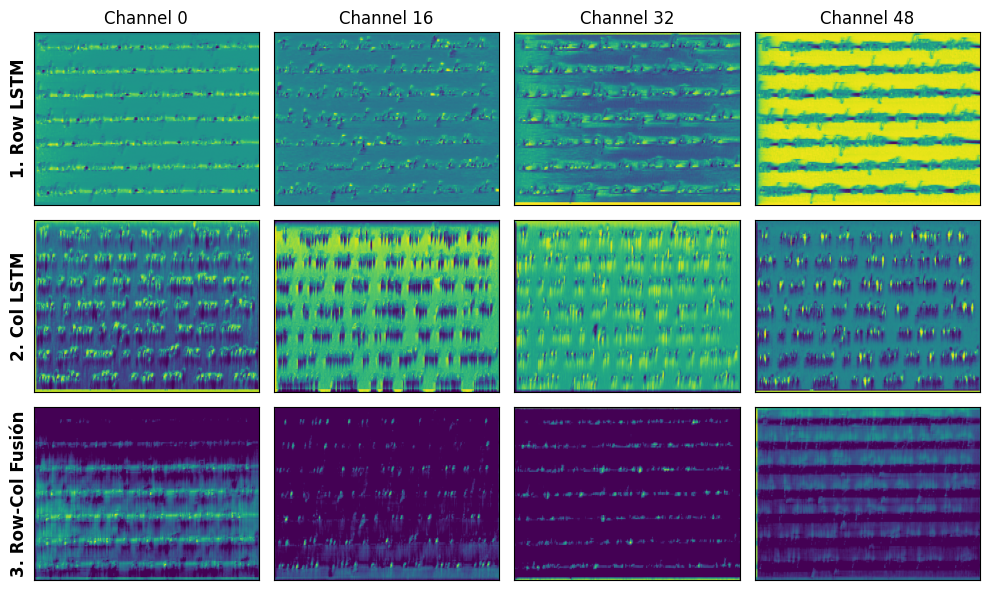


📝 Predicción Final                                             | Real Text

------------------------------------------------------------------------------------------------------------------------
To complete the job, screw two fittings to the               | To complete the job, screw two fittings to the
inside of the chair arms about 2 1/2 in. from the            | inside of the chair arms about 2 1/2 in. from the
back to nold the baby's safety harness. These can be         | back to hold the baby's safety harness. These can be
made by shaping and soldering two pieces of stout            | made by shaping and soldering two pieces of stout
wire as shown in Fig. 6. Make sure that these                | wire as shown in Fig. 6. Make sure that these
are well secured as they will have to withstand              | are well secured as they will have to withstand
considerable pulling as the child becomes older.             | considerable pulling as the child becomes older.
WER: 1.69%
CER: 0.

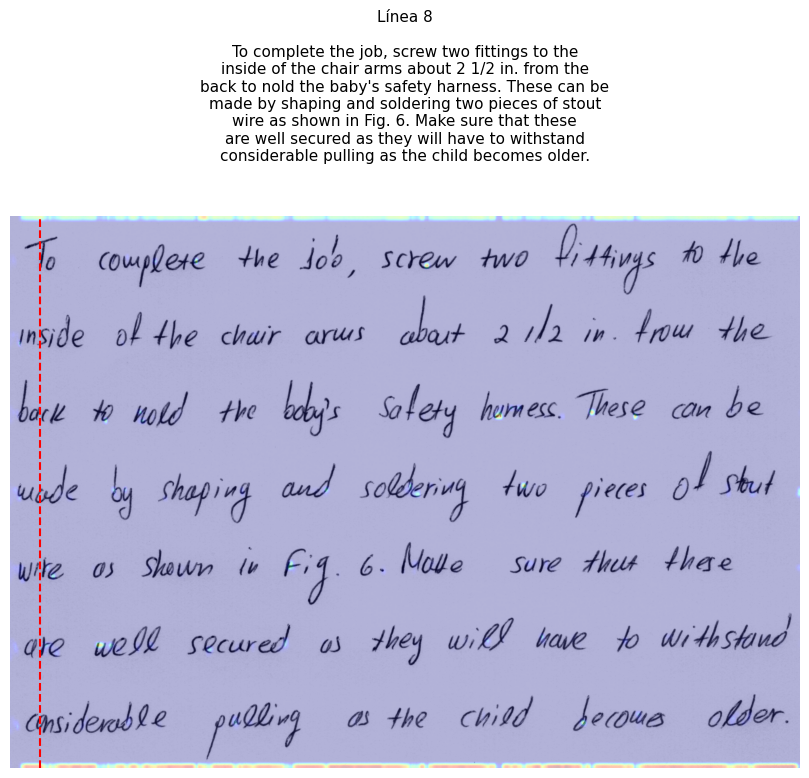

In [11]:
# ==========================================
# 1. CARGA DEL MODELO
# ==========================================
import pandas as pd
dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {dispositivo}")
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 200.0
# Instanciar el modelo con TU arquitectura (Asegúrate de que NUM_CLASES esté definido arriba)
modelo = FullParagraphHTR(num_clases=NUM_CLASES, hidden_size=256, max_lines=13).to(dispositivo)

RUTA_PESOS = '../models/weights/htr_full_mejor_modelo_v4.pth' 
RUTA_IMAGEN = 'a01-000u_full.png'
RUTA_IMAGEN = '../iam/paragraphs/e04-030_full.png'
#RUTA_IMAGEN = 'lt.jpeg'
df = pd.read_csv('../iam/labels/full_paragraphs.csv')


def estimar_altura_letras(ruta_imagen):
    # 1. Leer la imagen
    img = cv2.imread(ruta_imagen)
    if img is None:
        raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

    # 2. Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Aplicar un ligero desenfoque para reducir el ruido del papel
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 4. Binarizar la imagen (convertir a blanco puro y negro puro)
    # THRESH_BINARY_INV invierte los colores para que las letras sean blancas y el fondo negro,
    # lo cual es necesario para que findContours funcione correctamente.
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 5. Encontrar los contornos de los trazos
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    alturas = []
    for contorno in contornos:
        # Obtener el rectángulo delimitador (x, y, ancho, alto) de cada letra/trazo
        x, y, w, h = cv2.boundingRect(contorno)

        # 6. Filtrar ruido: ignoramos cosas muy pequeñas (puntos, polvo) 
        # o demasiado grandes (si tomó toda la hoja por error)
        if 15 < h < 300 and 5 < w < 300: 
            alturas.append(h)

    # Si no se encontró nada, devolvemos 0
    if not alturas:
        return 0

    # 7. Usar la mediana (es mucho más robusta que el promedio para ignorar valores atípicos)
    altura_aproximada = np.median(alturas)

    return altura_aproximada

print(f"Cargando pesos desde: {RUTA_PESOS}")
try:
    estado_diccionario = torch.load(RUTA_PESOS, map_location=dispositivo, weights_only=True)
    modelo.load_state_dict(estado_diccionario)
    modelo.eval()
    print("¡Modelo cargado con éxito! Las llaves coinciden perfectamente.")
except Exception as e:
    print(f"Error al cargar los pesos: {e}")


def preparar_imagen_inferencia(ruta_img, alto_modelo=1024, limite_maximo_ancho=1536):
    print(f"Preparando imagen: {ruta_img}")
    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    
    # 1. LIMPIEZA DINÁMICA (Binarización si es foto oscura)
    brillo_fondo = np.percentile(img, 95)
    if brillo_fondo < 200:
        print("📸 Foto detectada. Aplicando limpieza de fondo...")
        img_limpia = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 15)
    else:
        print("📄 Documento limpio detectado.")
        img_limpia = img
    color_fondo_padding = int(np.percentile(img_limpia, 90)) 

    limite_maximo_ancho = 1536
    
    alto_orig = img_limpia.shape[0]
    ancho_orig = img_limpia.shape[1]
    target_dimension = 45 # Tamaño ideal de letra que la red aprendió

    altura_letras = estimar_altura_letras(ruta_img)
    print(f"Altura estimada de letras: {altura_letras:.2f} px")
    if altura_letras >50:
        print("⚠️ La imagen tiene letras muy grandes. Aplicando escala basada en altura de letras.")
        factor_escala_letras = target_dimension / altura_letras
        nuevo_alto = int(alto_orig * factor_escala_letras)
        nuevo_ancho = int(ancho_orig * factor_escala_letras)
    else:
        factor_escala = min(1024 / alto_orig, limite_maximo_ancho / ancho_orig)
        
        nuevo_alto = max(1, int(alto_orig * factor_escala))
        nuevo_ancho = max(1, int(ancho_orig * factor_escala))
    
    # Redimensionamos la imagen
    img_resized = cv2.resize(img_limpia, (nuevo_ancho, nuevo_alto))
    
    # =======================================================
    # 2. PADDING VERTICAL (Fondo Blanco)
    # =======================================================
    # Si la imagen chocó con los 1536px de ancho, su alto será menor a 1024px.
    # Rellenamos el espacio sobrante hacia abajo con blanco (255)
    if nuevo_alto < 1024:
        pad_abajo = 1024 - nuevo_alto
        img_resized = cv2.copyMakeBorder(img_resized, 0, pad_abajo, 0, 0, cv2.BORDER_CONSTANT, value=color_fondo_padding)
    tensor_img = torch.from_numpy((img_resized / 255.0).astype(np.float32)).unsqueeze(0).unsqueeze(0)

    return tensor_img.to(dispositivo), img_resized
   
img_tensor, img_fondo = preparar_imagen_inferencia(RUTA_IMAGEN)

# ==========================================
# 3. INFERENCIA Y BARRIDO SUAVE
# ==========================================
print("🔍 Ejecutando inferencia...")
with torch.no_grad():
    logits, mapas_atencion_tensores,x_spatial, x_row, x_col = modelo(img_tensor)

# Dimensiones
b, c, h, w_cnn = mapas_atencion_tensores[0].shape
ancho_espaciador = 4
timesteps_por_linea = w_cnn + ancho_espaciador 
visualizar_canales_especificos(x_spatial, x_row, x_col, range(0, 64, 16))

# Decodificación y aplanado
probs = F.log_softmax(logits, dim=2)
pred_indices = probs.argmax(dim=2).cpu().numpy().flatten() 

frames_data = [] 
texto_acumulado = ""
idx_anterior = -1

for t, idx in enumerate(pred_indices):
    idx = int(idx)
    
    line_idx = t // timesteps_por_linea
    paso_horizontal = t % timesteps_por_linea
    
    # Calculamos la posición X basada en la imagen con padding
    x_pos = int((paso_horizontal / w_cnn) * img_fondo.shape[1])
    
    # Tu lógica original: ignoramos el 0 (Blank)
    if idx != 0 and idx != idx_anterior: 
        char = idx_a_char.get(idx, "")
        
        if char != "":
            texto_acumulado += char
            frames_data.append({
                'line_idx': line_idx,
                'x_pos': x_pos,
                'texto': texto_acumulado
            })
            
    idx_anterior = idx

real_text = df[df['image_id'] == f"{os.path.basename(RUTA_IMAGEN).split('.')[0]}.png"]['text'].values[0]
#real_text = "Hello, how are you I am good\nI am making this project for\ndeep learning class."

width = 60 

print(f"\n📝 {'Predicción Final':<{width}} | Real Text\n")
print("-" * (width + 60)) # Una línea separadora opcional para que se vea más limpio

for line1, line2 in zip(texto_acumulado.split('\n'), real_text.split('\n')):
    # :<{width} alinea el texto a la izquierda y lo rellena con espacios hasta llegar a 75 caracteres
    print(f"{line1:<{width}} | {line2}")
error = wer(real_text, texto_acumulado)
errorc = cer(real_text, texto_acumulado)
print(f"WER: {error:.2%}")
print(f"CER: {errorc:.2%}")

# ==========================================
# 4. ANIMACIÓN CINEMÁTICA INTERACTIVA
# ==========================================
if len(texto_acumulado) == 0:
    print(" No se predijo ningún texto válido.")
else:
    print("Generando animación fluida de lectura...")
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.subplots_adjust(top=0.8)

   

    # Preparar mapas de atención
    resized_maps = []
    for mapa in mapas_atencion_tensores:
        mapa_np = mapa.squeeze().cpu().numpy()
        mapa_np = (mapa_np - mapa_np.min()) / (mapa_np.max() - mapa_np.min() + 1e-8)
        mapa_resized = cv2.resize(mapa_np, (img_fondo.shape[1], img_fondo.shape[0]))

        resized_maps.append(mapa_resized)

     # Dibujamos el fondo UNA SOLA VEZ
    im_fondo = ax.imshow(img_fondo, cmap='gray')
    # Inicializamos el mapa de calor vacío
    im_mapa = ax.imshow(
    np.zeros_like(resized_maps[0]), 
    cmap='jet', 
    alpha=0.3, 
    animated=True, 
    vmin=0, 
    vmax=1
    )

    # Línea roja
    linea_v = ax.axvline(x=0, color='red', linewidth=1.5, linestyle='--', animated=True)

    # Texto (También debe ser animado para blit=True)
    titulo = ax.text(0.5, 1.1, "", transform=ax.transAxes, ha="center", fontsize=11, animated=True)

    ax.axis('off')

    def update(frame_idx):
        data = frames_data[frame_idx]
        line_idx, x_pos, texto_actual = data['line_idx'], data['x_pos'], data['texto']
        
        # Solo actualizamos los datos de los objetos existentes
        im_mapa.set_data(resized_maps[line_idx])
        linea_v.set_xdata([x_pos, x_pos])
        
        # Actualizar el vspan es un poco más complejo, así que lo movemos:
        # (Opcional: puedes quitar el vspan si quieres máxima velocidad)
        
        titulo.set_text(f"Línea {line_idx + 1}\n\n{texto_actual}")
        
        return [im_mapa, linea_v, titulo]

    # interval=40 es aprox 25 fps. blit=True es la clave de la velocidad.
    ani = animation.FuncAnimation(fig, update, frames=len(frames_data), 
                                interval=100, blit=True)
    # Guardar la animación
    # Solo necesitas tener 'Pillow' instalado (pip install Pillow)
    print("Generando GIF...")
    ani.save("../results/htr_lectura.gif", writer='pillow', fps=20)
    print("¡GIF guardado!")

    print("¡Video guardado con éxito!")
